In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("Summer-Olympic-medals-1976-to-2008.csv",encoding="latin-1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15433 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.3+ MB


In [39]:
#number of missing values
print("=== MISSING VALUES BEFORE ===")
print(df.isnull().sum())
print(f"Total rows before: {len(df)}")

=== MISSING VALUES BEFORE ===
City            0
Year            0
Sport           0
Discipline      0
Event           0
Athlete         0
Gender          0
Country_Code    0
Country         0
Event_gender    0
Medal           0
dtype: int64
Total rows before: 15315


In [38]:
df=df.dropna()
#number of missing values after cleaning
print("\n=== MISSING VALUES AFTER ===")
print(df.isna().sum())
print(f"Total rows after: {len(df)}")


=== MISSING VALUES AFTER ===
City            0
Year            0
Sport           0
Discipline      0
Event           0
Athlete         0
Gender          0
Country_Code    0
Country         0
Event_gender    0
Medal           0
dtype: int64
Total rows after: 15315


In [40]:
#number of duplicated values
print("\n=== DUPLICATES BEFORE ===")
print(f"Duplicate rows: {df.duplicated().sum()}")


=== DUPLICATES BEFORE ===
Duplicate rows: 0


In [41]:
df=df.drop_duplicates()
#after removing duplicates values
print("\n=== DUPLICATES AFTER ===")
print(f"Duplicate rows: {df.duplicated().sum()}")


=== DUPLICATES AFTER ===
Duplicate rows: 0


In [42]:
#ix data type (Year from float to int)
df["Year"]=df["Year"].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 15315 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   City          15315 non-null  object
 1   Year          15315 non-null  int64 
 2   Sport         15315 non-null  object
 3   Discipline    15315 non-null  object
 4   Event         15315 non-null  object
 5   Athlete       15315 non-null  object
 6   Gender        15315 non-null  object
 7   Country_Code  15315 non-null  object
 8   Country       15315 non-null  object
 9   Event_gender  15315 non-null  object
 10  Medal         15315 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.9+ MB


In [43]:
#Fix gender mismatch
print("\n=== GENDER MISMATCH BEFORE ===")
mis=df[(df["Gender"] == "Men") & (df["Event_gender"] == "W")]
print(f"Mismatch rows found: {len(mis)}")


=== GENDER MISMATCH BEFORE ===
Mismatch rows found: 1


In [44]:
# Remove mismatched rows
df = df.drop(mis.index)
mis_after = df[(df["Gender"] == "Men") & (df["Event_gender"] == "W")]
print(f"Mismatch rows remaining: {len(mis_after)}")

Mismatch rows remaining: 0


In [45]:
#Remove asterisk from country names
df["Country"] = df["Country"].str.strip().str.replace("*", "")


In [46]:
print("\n=== FINAL CLEANING SUMMARY ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Data types:\n{df.dtypes}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Unique countries: {df['Country'].nunique()}")


=== FINAL CLEANING SUMMARY ===
Total rows: 15314
Total columns: 11
Data types:
City            object
Year             int64
Sport           object
Discipline      object
Event           object
Athlete         object
Gender          object
Country_Code    object
Country         object
Event_gender    object
Medal           object
dtype: object
Missing values: 0
Unique countries: 127


Text(0, 0.5, 'number of medals')

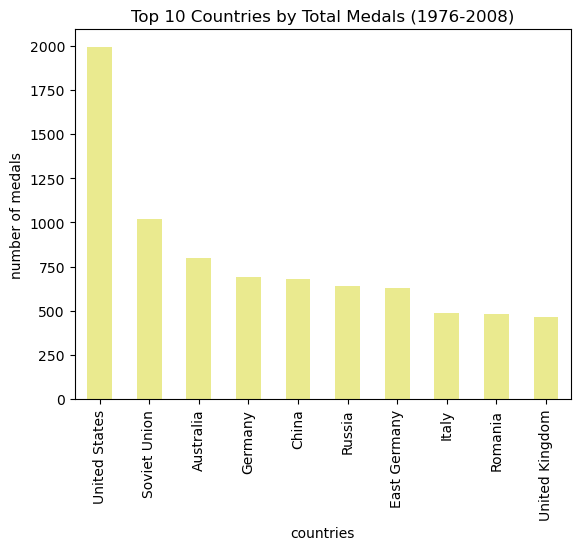

In [25]:
medals=df["Country"].value_counts().head(10)
medals.plot(kind="bar" ,color="#EAEA8F")
plt.title("Top 10 Countries by Total Medals (1976-2008)")
plt.xlabel("countries")
plt.ylabel("number of medals")



- **Why bar chart?** Best for comparing numerical values across distinct categories like countries.

- **Insights:** USA leads with over 2,000 medals. Soviet Union and Germany are distant second and third. China and Australia round out the top 5.

- **Patterns:** Massive gap between 1st and 2nd place. Top countries are large, wealthy nations.

- **What we learn:** These nations have the most successful Olympic programs and invest most heavily in sports.

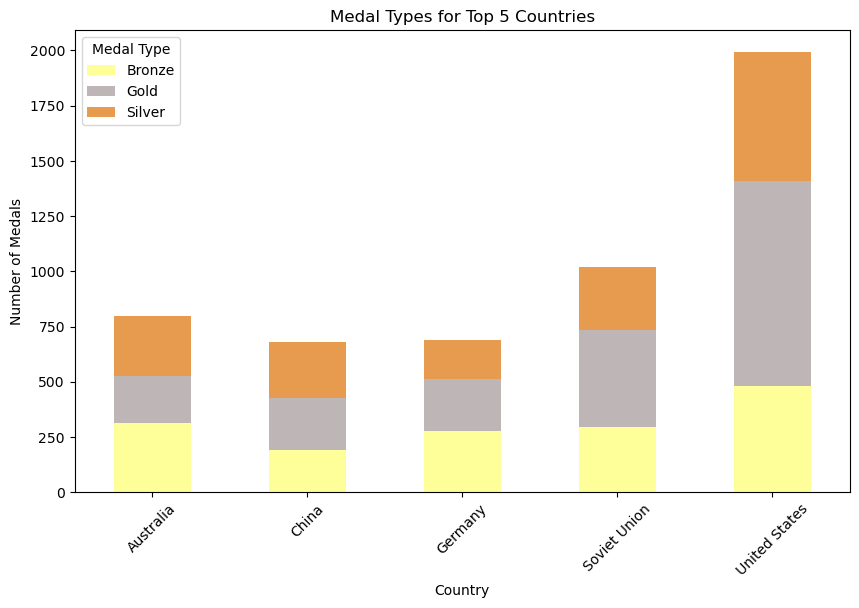

In [23]:
# Get medal types for top countries
top_5 = medals.head(5).index
df_top5 = df[df["Country"].isin(top_5)]
medal_types = df_top5.groupby(["Country", "Medal"]).size().unstack()
medal_types.plot(kind="bar", stacked=True, color=["#FFFF9A", "#BEB6B6", "#E79B4F"], figsize=(10, 6))
plt.title("Medal Types for Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)
plt.legend(title="Medal Type")
plt.show()


- **Why stacked bar chart?** Shows both total medals AND medal type (gold vs silver vs bronze).

- **Insights:** USA leads in gold medals. Distribution varies by country.

- **Patterns:** Higher gold percentage indicates better elite training.

- **What we learn:** Gold medals matter more than total medals.

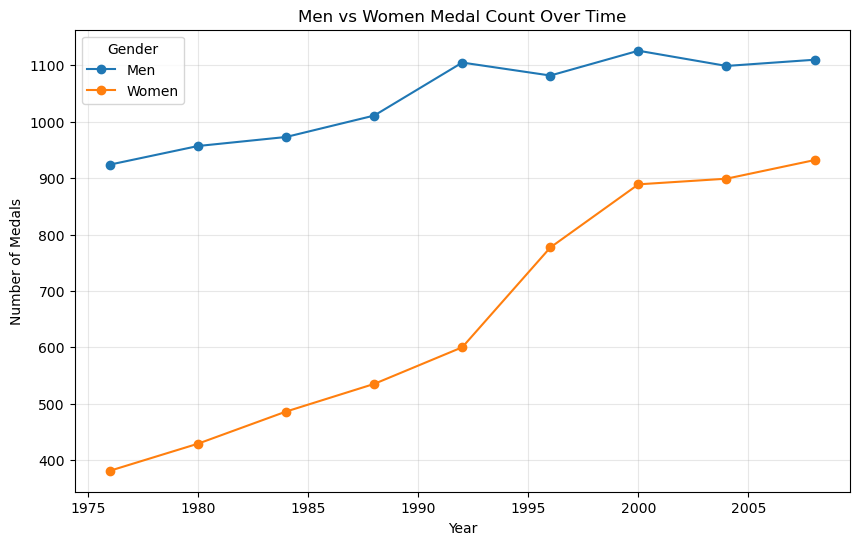

In [36]:
gender_year = df[["Year", "Gender"]].groupby(["Year", "Gender"]).size().unstack()
gender_year.plot(kind="line", marker="o", figsize=(10, 6))
plt.title("Men vs Women Medal Count Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.grid(True, alpha=0.3)
plt.show()


- **Why line chart?** Shows how two categories trend differently across the same time period.

- **Insight:** Women's medals increased dramatically (from ~500 to ~1,600). Men's medals stayed stable (~1,400–1,600). Women nearly matched men by 2008.

- **Patterns:** The gender gap closed significantly over 30 years.

- **What we learn:** Women's opportunities in sports grew significantly over 30 years. More women's events were added to the Olympics.

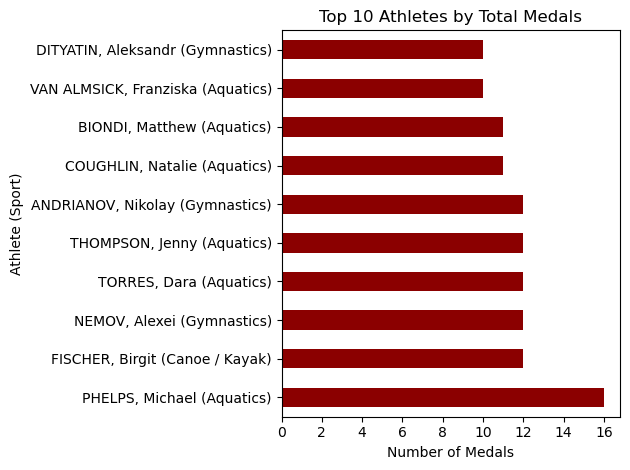

In [32]:
# Get top 10 athletes with their sport
top_athletes = df.groupby(['Athlete', 'Sport']).size().reset_index(name='Medals')
top_athletes = top_athletes.sort_values('Medals', ascending=False).head(10)
top_athletes['Label'] = top_athletes['Athlete'] + " (" + top_athletes['Sport'] + ")"
 
top_athletes.set_index('Label')['Medals'].plot(kind="barh", color="darkred")
plt.title("Top 10 Athletes by Total Medals")
plt.xlabel("Number of Medals")
plt.ylabel("Athlete (Sport)")
plt.tight_layout()
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()


- **Why horizontal bar chart?** Makes long athlete names readable and allows easy ranking comparison.

- **Insight:** Michael Phelps leads with 16 medals. Birgit Fischer and Alexei Nemov follow. Most top athletes are swimmers or gymnasts.

- **Patterns:** Swimmers dominate because they compete in many events

- **What we learn:** Sports with multiple events allow athletes to accumulate more medals than sports with just one event.

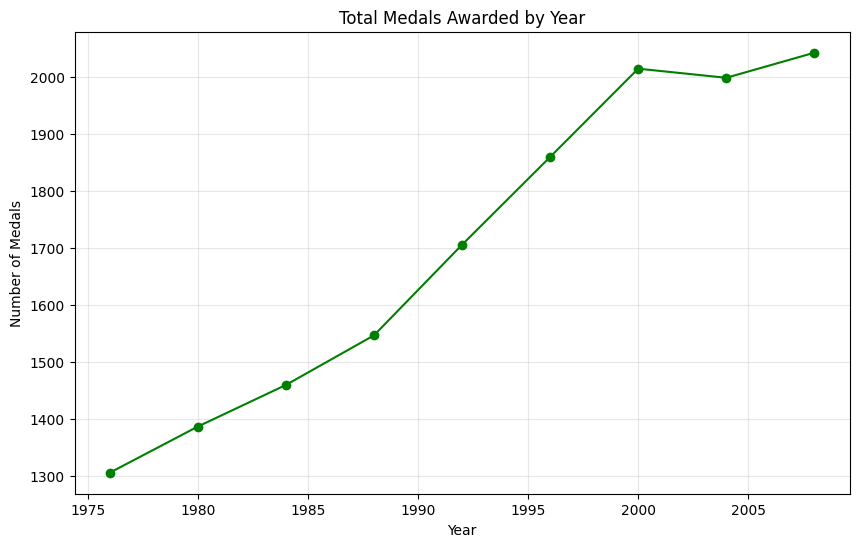

In [ ]:
yearly_total = df.groupby("Year").size()
yearly_total.plot(kind="line", marker="o", color="green", figsize=(10, 6))
plt.title("Total Medals Awarded by Year")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.grid(True, alpha=0.3)
plt.show()


- **Why line chart?** Perfect for showing trends and changes across multiple Olympic years.

- **Insight:** Medal counts increased steadily from 1976 to 2008. There is a consistent upward trend with no major drops. The Olympics awarded significantly more medals in 2008 than in 1976.

- **Patterns:** Overall upward trend.

- **What we learn:** The Olympic program expanded over time by adding more sports, events, and allowing more athletes to compete.

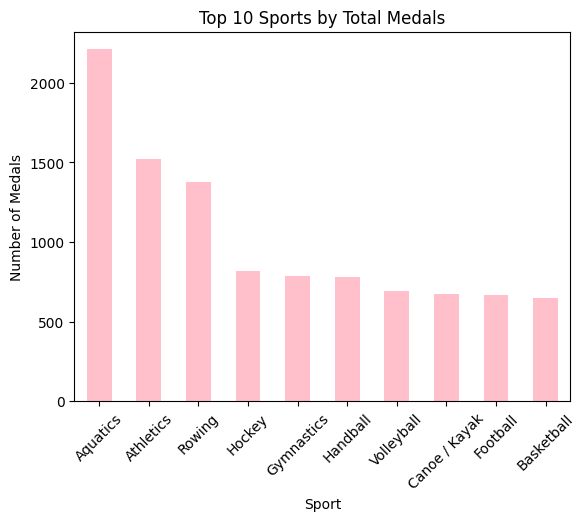

In [ ]:
sports = df["Sport"].value_counts().head(10)
sports.plot(kind="bar", color="pink")
plt.title("Top 10 Sports by Total Medals")
plt.xlabel("Sport")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)
plt.show()


- **Why bar chart?** Clearly shows which sports award the most medals at a glance.

- **Insight:** Aquatics leads with over 2,000 medals. Athletics (track/field) is second. Other sports like Basketball and Football are far behind.

- **Patterns:** The gap between #1 and #2 is large. Medal-rich sports have many event categories.

- **What we learn:** Countries that invest in swimming and track have the most opportunities to win medals.

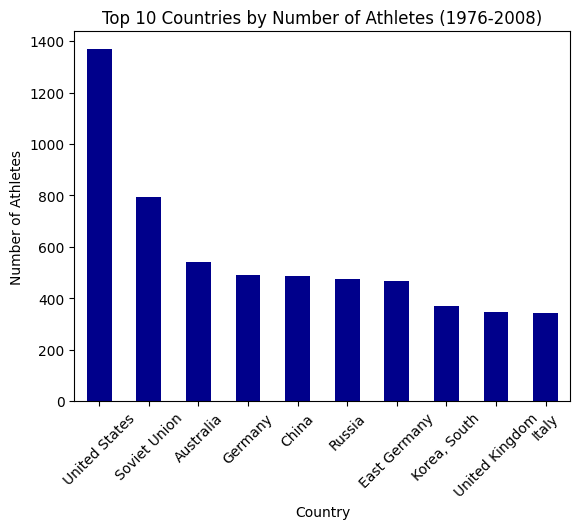

In [ ]:
athletes_per_country = df.groupby('Country')['Athlete'].nunique().sort_values(ascending=False).head(10)

athletes_per_country.plot(kind="bar", color="darkblue")
plt.title("Top 10 Countries by Number of Athletes (1976-2008)")
plt.xlabel("Country")
plt.ylabel("Number of Athletes")
plt.xticks(rotation=45)
plt.show()


- **Why bar chart?** Compares participation size across nations.

- **Insight:** USA sends the most athletes (over 1,500). Soviet Union, Australia, and Germany follow. Large wealthy nations dominate the list.

- **Patterns:** Athlete count generally correlates with medal count but not perfectly.

- **What we learn:** Sending many athletes requires financial investment. Some nations send many athletes but win fewer medals per athlete.

